# Pizza Sales Data Analysis

## Assignment 3

This notebook analyses the 2015 pizza sales dataset to answer a series of business questions using Python, Pandas, and Matplotlib.

In [521]:

#Import the libraries required for data manipulation and visualization

import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [522]:
from zipfile import ZipFile

zip_file = ZipFile('Pizza+Place+Sales.zip')

#to display the paths of all the files in the ZIP

zip_file.namelist()

['data_dictionary.csv',
 'pizza_sales/',
 'pizza_sales/orders.csv',
 'pizza_sales/order_details.csv',
 'pizza_sales/pizzas.csv',
 'pizza_sales/pizza_types.csv']

In [523]:
# Read the four datasets into separate DataFrames


zip_file = ZipFile(zip_path)

orders = pd.read_csv(zip_file.open('pizza_sales/orders.csv'))

order_details = pd.read_csv(zip_file.open('pizza_sales/order_details.csv'))

pizzas = pd.read_csv(zip_file.open('pizza_sales/pizzas.csv'))

pizza_types = pd.read_csv(zip_file.open('pizza_sales/pizza_types.csv'), encoding='latin1')

In [524]:
orders

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30
...,...,...,...
21345,21346,2015-12-31,20:51:07
21346,21347,2015-12-31,21:14:37
21347,21348,2015-12-31,21:23:10
21348,21349,2015-12-31,22:09:54


In [525]:
order_details

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1
48616,48617,21348,four_cheese_l,1
48617,48618,21348,napolitana_s,1
48618,48619,21349,mexicana_l,1


In [526]:
pizzas

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75
...,...,...,...,...
91,spinach_fet_m,spinach_fet,M,16.00
92,spinach_fet_l,spinach_fet,L,20.25
93,veggie_veg_s,veggie_veg,S,12.00
94,veggie_veg_m,veggie_veg,M,16.00


In [527]:
pizza_types

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
8,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."


In [528]:
## Data Inspection

#The first five rows of orders are displayed to understand their structure and identify the available variables before merging.


orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [529]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [530]:
## Data Inspection

#The first five rows of order_details are displayed to understand their structure and identify the available variables before merging.

order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [531]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [532]:

## Data Inspection

#The first five rows of pizzas are displayed to understand their structure and identify the available variables before merging.

pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [533]:
pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [534]:

## Data Inspection

#The first five rows of pizza_types are displayed to understand their structure and identify the available variables before merging.

pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [535]:
pizza_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


##Merge the Datasets

## Data Preparation

The four datasets are merged using **inner joins** based on their common keys to create a single dataset for analysis. This ensures that only matching records from all datasets are included.

In [536]:
# Merge the datasets into a single DataFrame using inner joins

## Merge the orders dataset with the order_details dataset

sales = pd.merge(order_details, orders, on='order_id', how='inner')

## Merge the sales dataset with the pizzas dataset

sales = pd.merge(sales, pizzas, on='pizza_id', how='inner')

## Merge the sales dataset with the pizza_types dataset

sales= pd.merge(sales, pizza_types, on='pizza_type_id', how='inner')

##### Merged Dataset Preview

The merged dataset is displayed below to verify that the datasets were successfully combined and to inspect the structure of the final DataFrame before analysis.

In [537]:
sales

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [538]:
sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [539]:
sales.shape

(48620, 12)

In [540]:
## Data Types

#The data types of each column are examined to ensure that each variable is stored in the appropriate format for analysis.

sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [541]:
##The dataset is checked for missing values to determine whether any cleaning is required before analysis.

sales.isna().sum()

,0
order_details_id,0
order_id,0
pizza_id,0
quantity,0
date,0
time,0
pizza_type_id,0
size,0
price,0
name,0


In [542]:
##The dataset is checked for duplicated values to determine whether any cleaning is required before analysis.

sales.duplicated().sum()

np.int64(0)

####Insight
The dataframe contains no missing or duplicated values, indicating that the data is complete and suitable for analysis without requiring imputation or the removal of incomplete or duplicated records.

In [543]:
# Convert the date and time columns to datetime format

sales['date'] = pd.to_datetime(sales['date'])

sales['time'] = pd.to_datetime(sales['time'])


sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  datetime64[ns]
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(6)
memory usage: 4.5+ MB


#####INSIGHT

Most columns were stored using appropriate data types. However, the date and time columns were converted to datetime data types to facilitate time-based analysis such as identifying peak hours, weekdays, and monthly sales trends.

#####Data Exploration

######Observation period

To understand the timespan covered by the dataset, we determine the earliest and latest order dates

This helps to identify the period during which the sales were recorded

In [544]:
#To determine the period during which the records were made

first_date = sales['date'].min()
last_date = sales['date'].max()

print(f'The first date the sales were recorded was {first_date}, while the last date is {last_date}')

The first date the sales were recorded was 2015-01-01 00:00:00, while the last date is 2015-12-31 00:00:00


###INSIGHT

The dataset contains sales records from 2015-01-01 00:00:00 to 2015_12_31 00:00:00

This shows that records cover one year of pizza sales

## **TOTAL REVENUE/SALES**
To calculate the revenue/sales for each transaction, the quantity of the pizzas sold is multiplied by the price of each pizza.

    Revenue= Quantity * Price

The revenue from all transactions is then summed to obtain the total revenue generated by the pizza place

In [545]:
#To find the total revenue/sales of the Pizza place

sales['revenue'] = sales['quantity'] * sales['price']

total_revenue = sales['revenue'].sum()

total_revenue

print(f'Total Revenue Generated: {total_revenue}')

Total Revenue Generated: 817860.05


###INSIGHTS

The pizza place generated **817860.05** in total revenue during the period covered by the dataset.

This indicates the overall sales performance of the pizza place and provides a baseline for further analysis. Comparing this revenue with sales by month, day of the week, and pizza category can help identify the factors that contributed most to the business performance.

##**TOTAL QUANTITY SOLD**


In [546]:
# Calculate the total number of pizzas sold

total_quantity = sales['quantity'].sum()

print(f'Total Quantity Sold: {total_quantity} pizzas')

Total Quantity Sold: 49574 pizzas


####INSIGHT


A total of **49,574 pizzas** were sold during the observed period. This reflects a high level of customer demand and provides an indication of the restaurant's overall sales volume throughout the year.

##**TOTAL ORDERS**

The total number of orders shows how many separate customer purchases were made

In [547]:
sales['order_id'].value_counts()

,count
order_id,
18845,21
10760,21
20163,15
13906,15
18280,15
...,...
13126,1
7,1
21327,1


In [548]:
# Calculate the total number of customer orders

total_orders = sales['order_id'].nunique()
print(f'Total Customer Orders: {total_orders}')

Total Customer Orders: 21350


####INSIGHT

The restaurant processed **21,350 customer orders** during the observed period. This represents the total number of transactions completed and provides insight into customer purchasing activity throughout the year.

##NUMBER OF PIZZA TYPES SOLD

This analysis determines the number of unique pizza types/varieties available on the menu

In [549]:
sales['name'].value_counts()

,count
name,
The Classic Deluxe Pizza,2416
The Barbecue Chicken Pizza,2372
The Hawaiian Pizza,2370
The Pepperoni Pizza,2369
The Thai Chicken Pizza,2315
The California Chicken Pizza,2302
The Spicy Italian Pizza,1887
The Sicilian Pizza,1887
The Southwest Chicken Pizza,1885


In [550]:
# Determine the number of unique pizza types offered

pizza_types_count = sales['name'].nunique()

print(f'Number of Pizza Types Sold: {pizza_types_count} pizza types')

Number of Pizza Types Sold: 32 pizza types


####INSIGHTS

The pizza place offers **32** different pizza types.

A wide variety of pizza options can help attract customers with different tastes and preferences.

##**AVERAGE PRICE OF PIZZAS**

The average pizza prices helpes us understand the general pricing strategy of the pizza place

In [551]:
#Calculate the average pizza price

average_price = sales['price'].mean()

print(f'Average price of pizzas: {average_price:.2f}')

Average price of pizzas: 16.49


####INSIGHTS

The average selling price of a pizza was **16.49**. This value provides an estimate of the typical price customers paid for pizzas and offers insight into the restaurant's pricing strategy.

##**PEAK HOUR OF SALES**

This analysis identifies the hours of the day during which the restaurant receives the highest number of orders.

Knowing the busiest hours helps with staff scheduling, inventory planning, and improving customer service.

In [552]:
#Extract the hour from the time
sales['hour'] = sales['time'].dt.hour

#Count orders by hour
hourly_sales = sales.groupby('hour')['order_id'].count()


hourly_sales

,order_id
hour,
9,4
10,17
11,2672
12,6543
13,6203
14,3521
15,3170
16,4185
17,5143


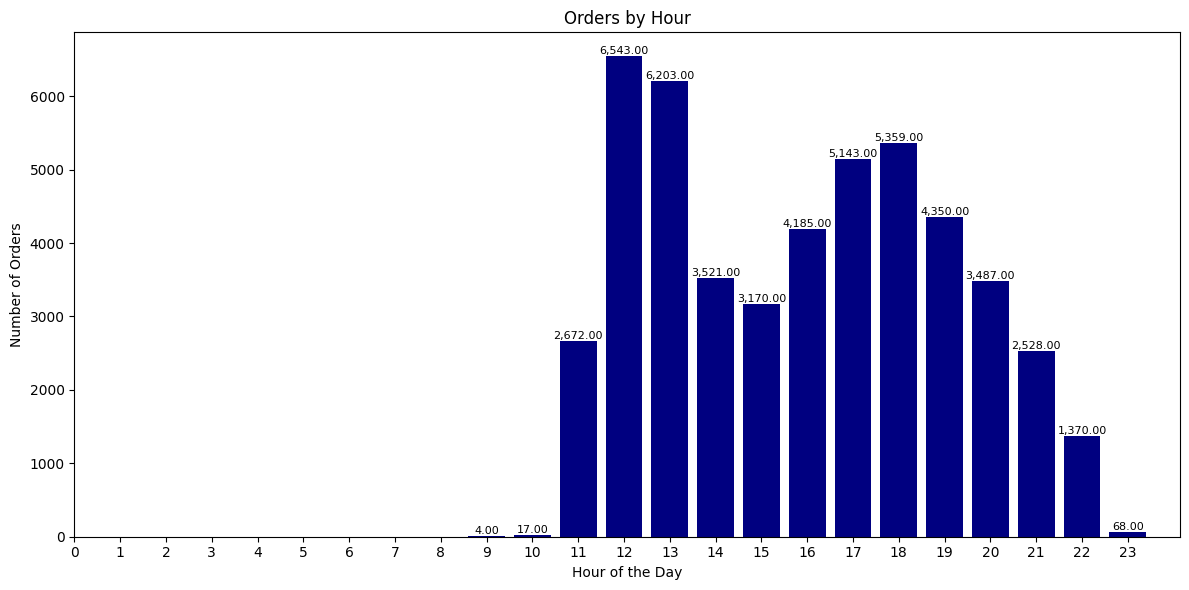


Peak sales period: 12PM - 1PM


In [590]:
#plot
# Create a bar chart showing the number of pizzas sold each hour
plt.figure(figsize=(12,6))
barplot = plt.bar(hourly_sales.index, hourly_sales.values, color='navy')

plt.title('Orders by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(range(24), rotation=0)

# Add formatted number of orders values above each bar
for bar in barplot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,.2f}", ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

peak_hour = hourly_sales.idxmax()

start = pd.to_datetime(f"{peak_hour}:00").strftime("%-I%p")
end = pd.to_datetime(f"{peak_hour + 1}:00").strftime("%-I%p")

print()
print(f"Peak sales period: {start} - {end}")

####INSIGHT

The chart shows the busiest hours of the day.

The analysis shows that pizza sales vary throughout the day, with the **highest customer demand occurring between 12:00 PM and 1:00 PM**, making it the peak sales period.

The chart also indicates that **1:00 PM to 2:00 PM** remained relatively busy, suggesting sustained customer demand during the lunchtime period. A second increase in sales was observed between **6:00 PM and 7:00 PM**, likely reflecting increased customer purchases during the evening dinner period.

Overall, the sales pattern suggests that customer demand is highest during traditional meal times, particularly **lunch and dinner**,

Management can schedule more staff during these hours to improve service efficiency and reduce waiting times.

##**TOTAL SALES MADE ON EACH DAY OF THE WEEK**

###DAY OF THE WEEK WHEN SALES ARE MADE THE MOST

This analysis determines which day generates the hishest revenue.

In [554]:
#to extract weekday names
sales['day'] = sales['date'].dt.day_name()

#to arrange days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_sales = (sales.groupby('day')['revenue'].sum().reindex(days_order))
day_sales


,revenue
day,
Monday,107329.55
Tuesday,114133.80
Wednesday,114408.40
Thursday,123528.50
Friday,136073.90
Saturday,123182.40
Sunday,99203.50


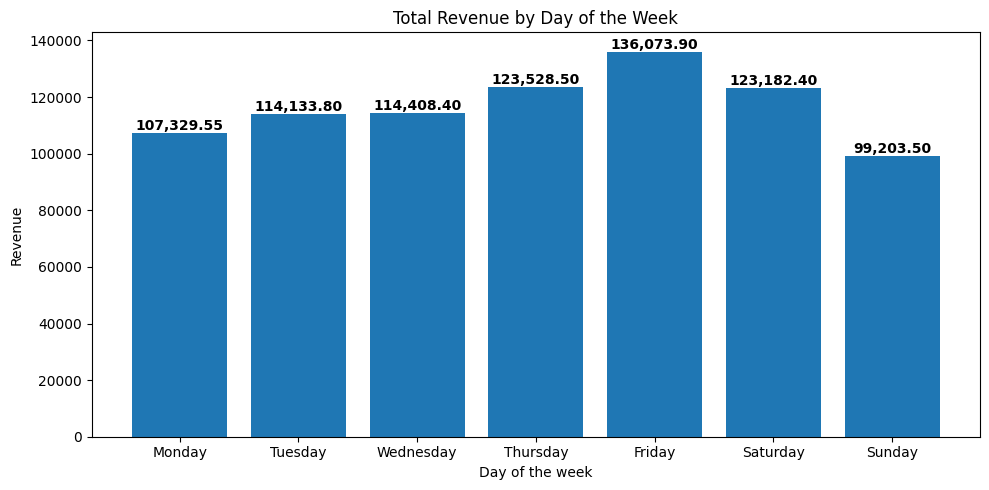


 Total Sales Made on each Day of the Week
-----------------------------------
Monday     : 107,329.55
Tuesday    : 114,133.80
Wednesday  : 114,408.40
Thursday   : 123,528.50
Friday     : 136,073.90
Saturday   : 123,182.40
Sunday     :  99,203.50

The day of the week when sales are made the most is Friday


In [555]:
#PLOT

plt.figure(figsize=(10, 5))

Bar= plt.bar(day_sales.index, day_sales.values, color='C10')

plt.title('Total Revenue by Day of the Week')
plt.xlabel('Day of the week')
plt.ylabel('Revenue')


# Add formatted revenue values above each bar
for bar in Bar:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


#Highest sales day
best_day = day_sales.idxmax()
print()

print(" Total Sales Made on each Day of the Week")
print("-" * 35)

for day, revenue in day_sales.items():
    print(f"{day:<10} : {revenue:>10,.2f}")
print()

print(f'The day of the week when sales are made the most is {best_day}')

####INSIGHT


The analysis shows that sales were generated on every day of the week, indicating consistent customer patronage throughout the observed period. **Friday** recorded the highest total revenue, making it the busiest sales day of the week. This may be attributed to increased customer demand as the weekend approaches.

Although sales fluctuated across the week, the differences between most weekdays were relatively small, suggesting a fairly stable sales pattern. **Sunday** recorded the lowest total revenue, indicating comparatively lower customer activity on that day.

##**TOP 5 BESTSELLING PIZZAS**

This analysis identifies the pizzas with the highest quantities sold.



In [556]:
top_pizzas = (sales.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5))

top_pizzas

,quantity
name,
The Classic Deluxe Pizza,2453
The Barbecue Chicken Pizza,2432
The Hawaiian Pizza,2422
The Pepperoni Pizza,2418
The Thai Chicken Pizza,2371


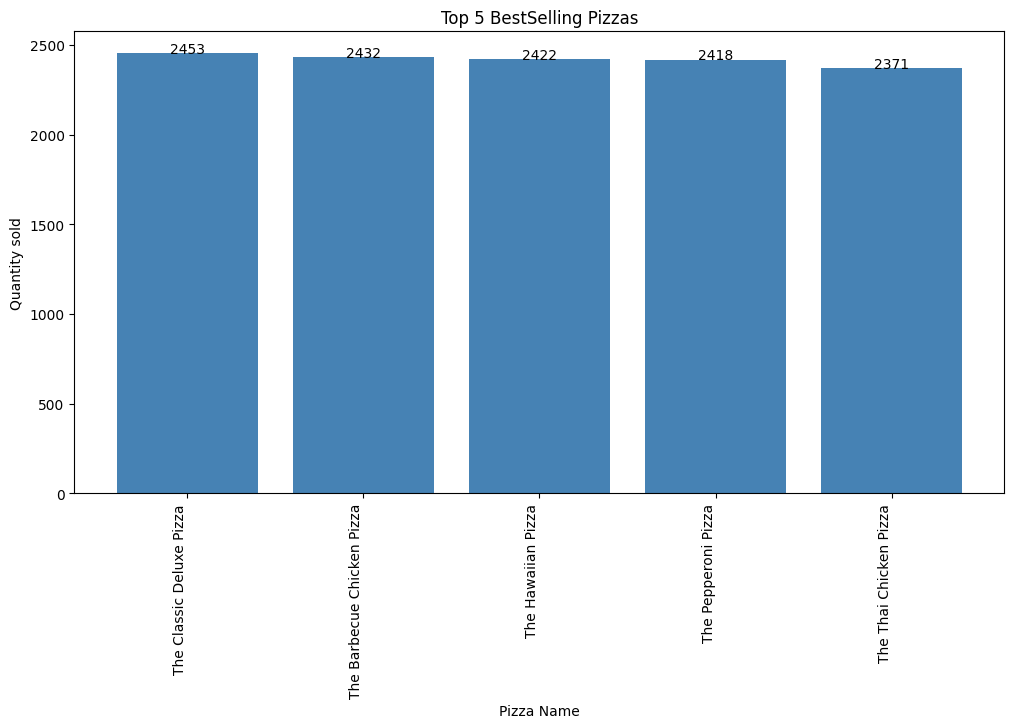


The top 5 selling pizzas are 
--------------------------------------------------
1. The Classic Deluxe Pizza - 2,453 pizzas sold
2. The Barbecue Chicken Pizza - 2,432 pizzas sold
3. The Hawaiian Pizza - 2,422 pizzas sold
4. The Pepperoni Pizza - 2,418 pizzas sold
5. The Thai Chicken Pizza - 2,371 pizzas sold


In [557]:
plt.figure(figsize=(12,6))
bars = plt.bar(top_pizzas.index, top_pizzas.values, color='steelblue')

for bar in bars:
  plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, int(bar.get_height()), ha='center')

plt.title('Top 5 BestSelling Pizzas')
plt.xlabel('Pizza Name')
plt.ylabel('Quantity sold')

plt.xticks(rotation=90, ha='right')


plt.show()


print()
print('The top 5 selling pizzas are ')
print('-' * 50)

count = 1
for pizza, Sales in top_pizzas.items():
  print(f'{count}. {pizza} - {Sales:,} pizzas sold')
  count += 1


####INSIGHTS

The top five pizzas account for a significant portion of total sales.

These pizzas are the strongest-performing menu items and should remain well-stocked to meet customer demand.

##SALES MADE IN EACH MONTH AND NOTICEABLE TRENDS

This analysis helps identify seasonal sales trends throughout the year.

In [558]:
#Extract month names

sales['month'] = sales['date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = sales.groupby('month')['revenue'].sum().reindex(month_order)

monthly_sales

,revenue
month,
January,69793.30
February,65159.60
March,70397.10
April,68736.80
May,71402.75
June,68230.20
July,72557.90
August,68278.25
September,64180.05


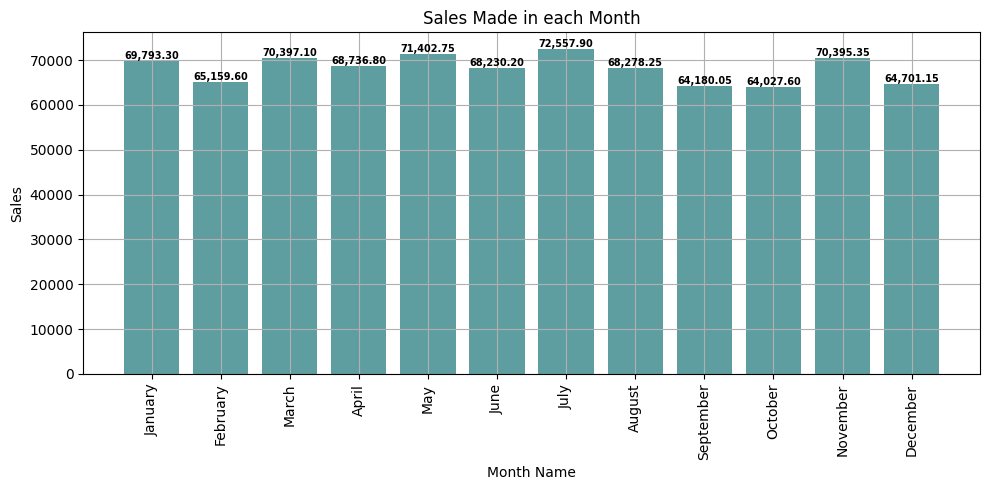

 Total Sales Made in each Month
---------------------------------------------
January    :  69,793.30
February   :  65,159.60
March      :  70,397.10
April      :  68,736.80
May        :  71,402.75
June       :  68,230.20
July       :  72,557.90
August     :  68,278.25
September  :  64,180.05
October    :  64,027.60
November   :  70,395.35
December   :  64,701.15



In [575]:
#PLOT
plt.figure(figsize=(10,5))

BAR = plt.bar(monthly_sales.index, monthly_sales.values, color='cadetblue')

plt.title('Sales Made in each Month')
plt.xlabel('Month Name')
plt.ylabel('Sales')

for bar in BAR:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,.2f}", ha='center', va='bottom', fontsize=7, fontweight='bold')


plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()

plt.show()

print(" Total Sales Made in each Month")
print("-" * 45)

for month, Sale in monthly_sales.items():
    print(f"{month:<10} : {Sale:>10,.2f}")
print()

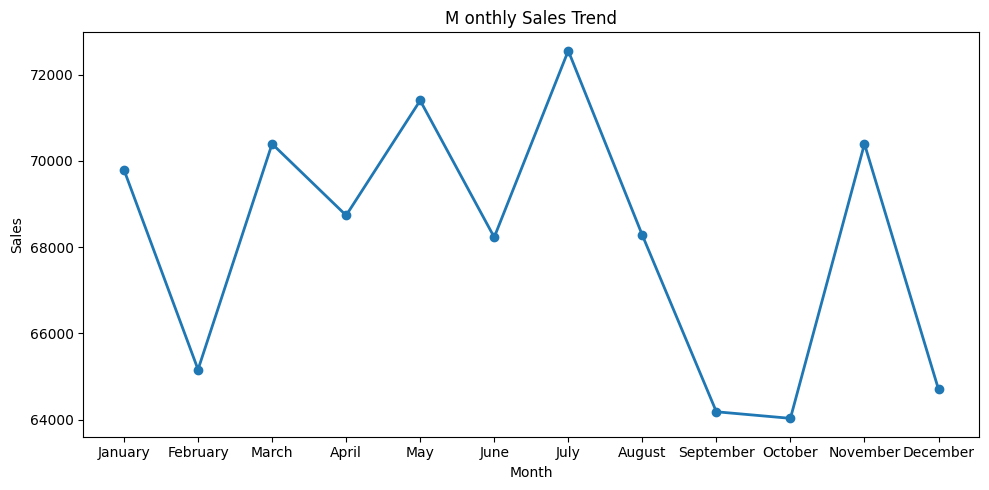

In [576]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker= 'o', linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

####INSIGHTS

The monthly sales remained relatively consistent throughout the year, with moderate flunctuations in revenue. Sales gradually increased during the first half of the year, reaching their highest level in **July**. Revenue then declined slightly between **August** and **October**, recovered in **November**, and fell slightly again in **December**.

Overall, the graphs suggest that the pizza place experienced consistent sales throughout the year, with no significant long-term upward or downward trend in revenue.

##**PIZZAS NOT DOING WELL ON THE MENU**

This analysis identifies the least-selling pizzas on the menu

In [560]:
selling_pizzas = (sales.groupby('name')['quantity'].sum().sort_values())
selling_pizzas

,quantity
name,
The Brie Carre Pizza,490
The Mediterranean Pizza,934
The Calabrese Pizza,937
The Spinach Supreme Pizza,950
The Soppressata Pizza,961
The Spinach Pesto Pizza,970
The Chicken Pesto Pizza,973
The Italian Vegetables Pizza,981
The Chicken Alfredo Pizza,987


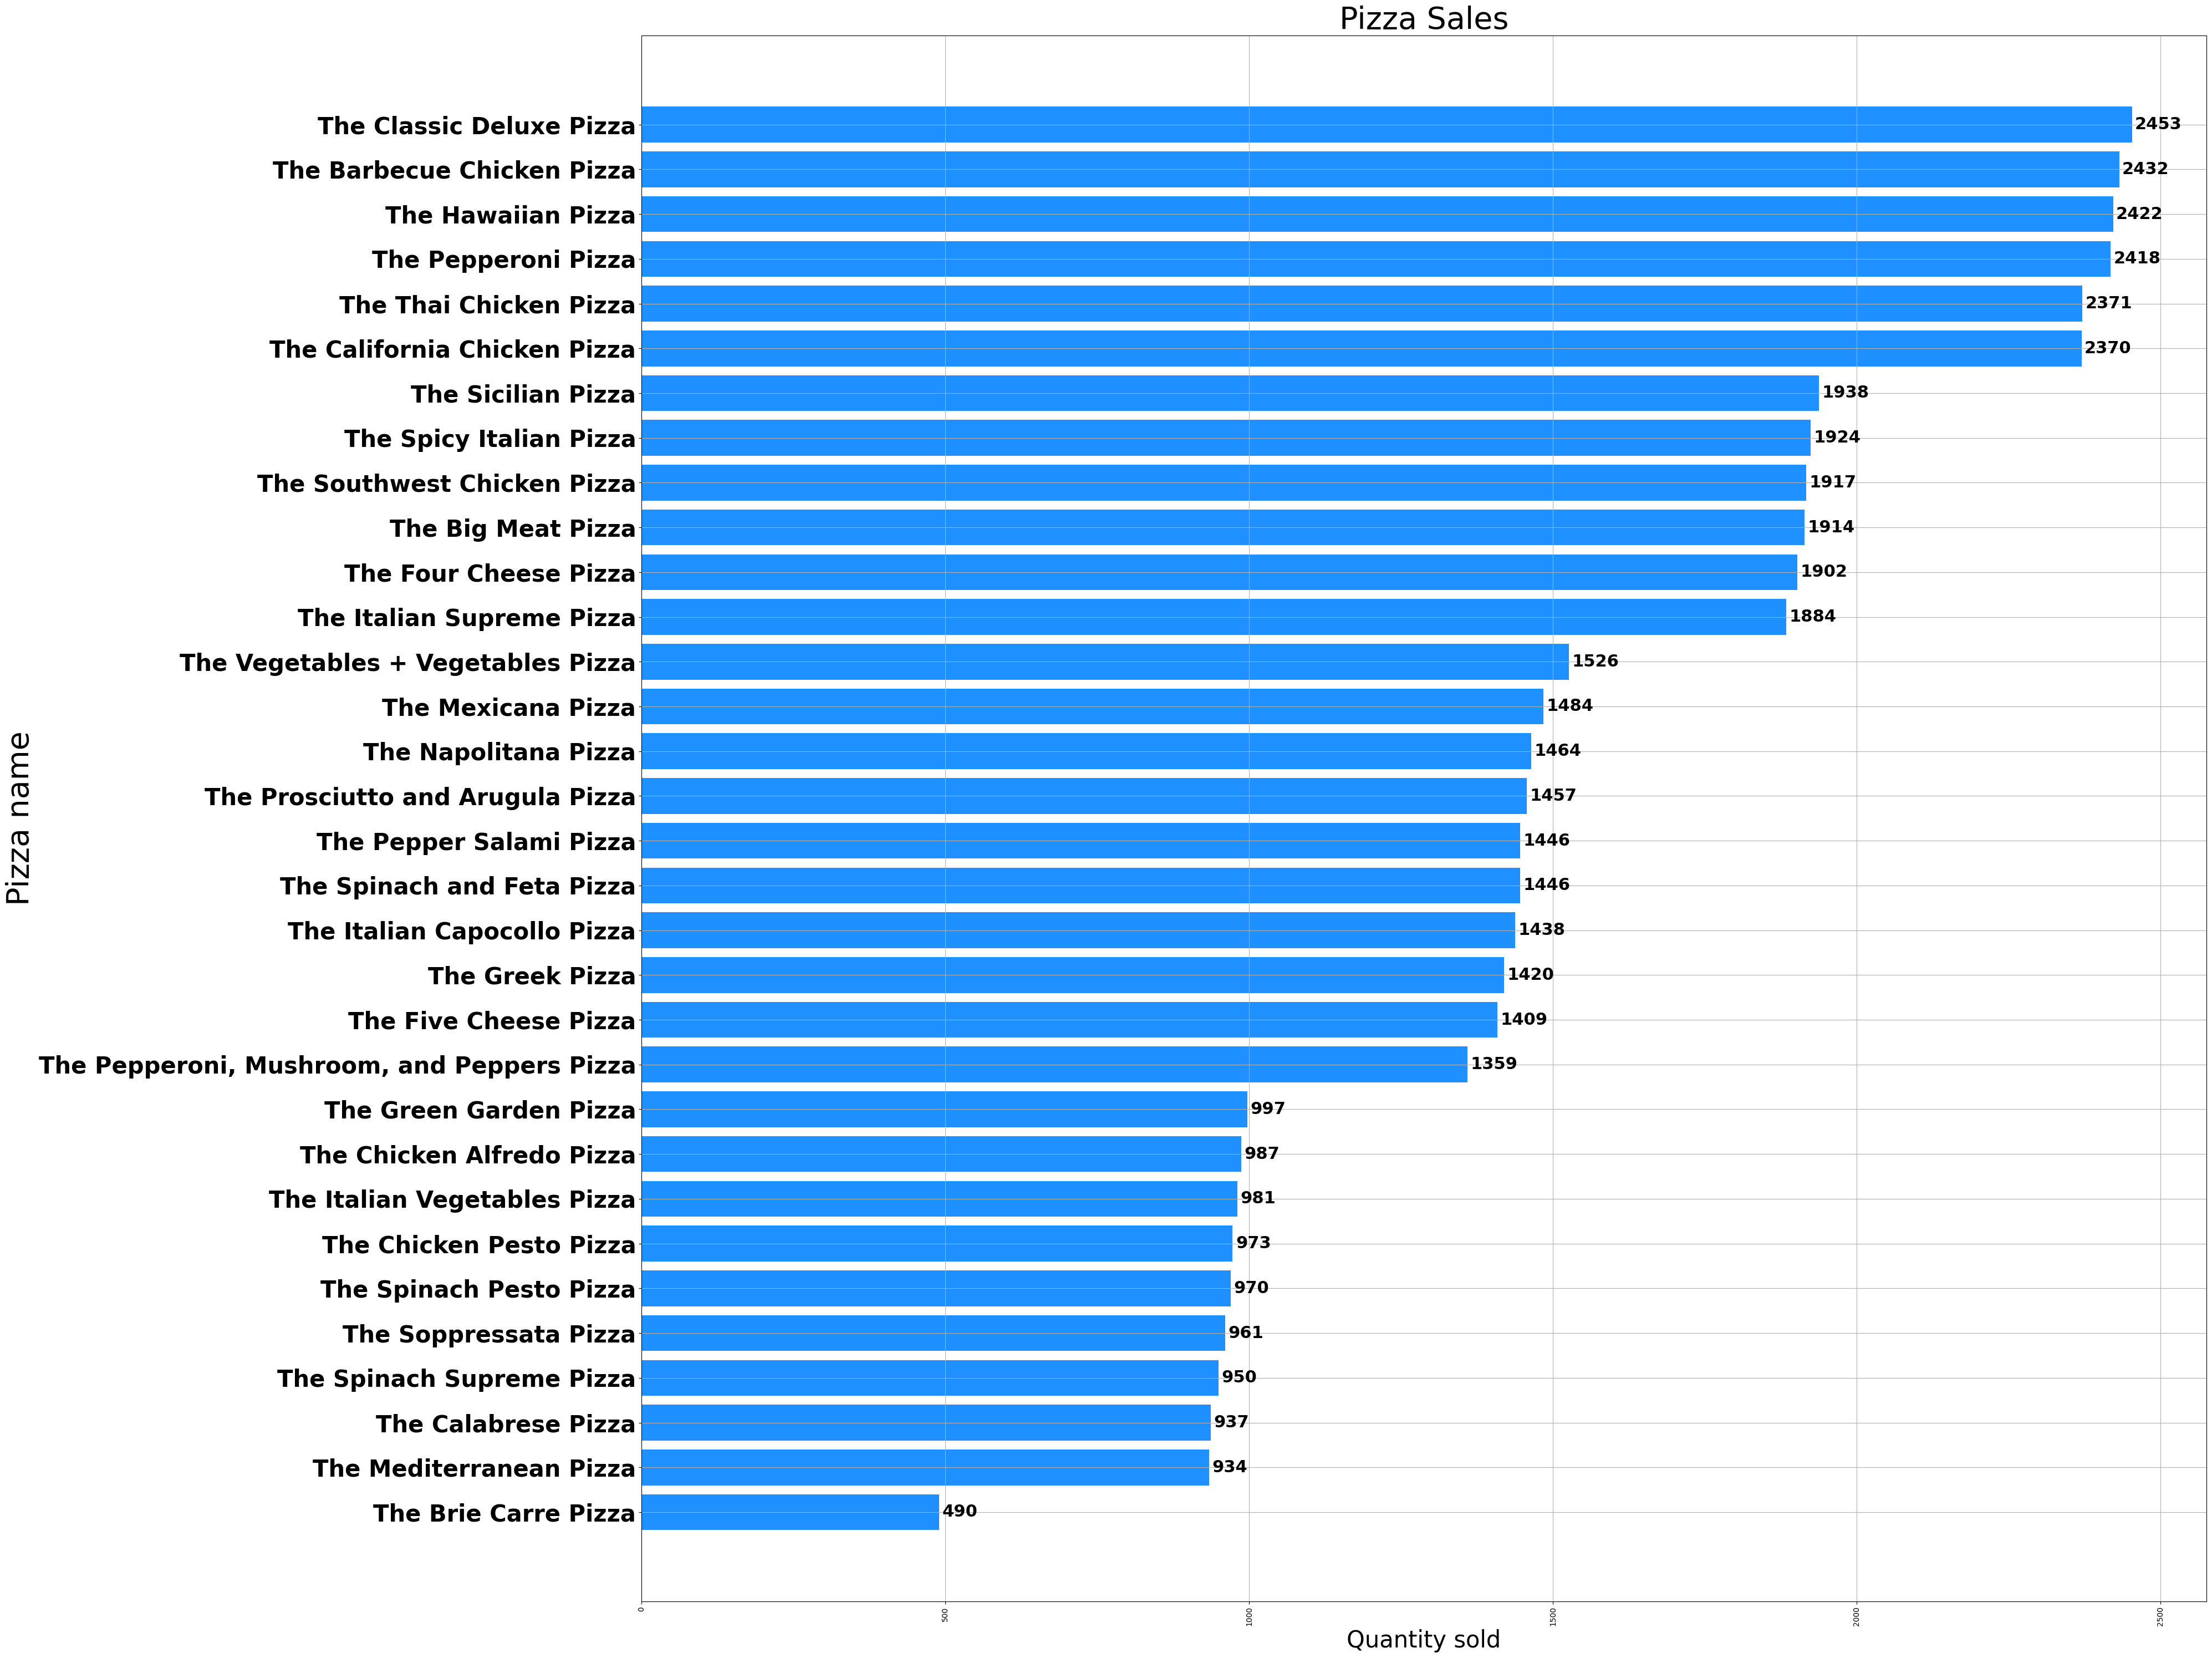


The pizza  that is not doing well on the menu is The Brie Carre Pizza, with 490 sales during the period.


In [561]:
plt.figure(figsize=(40,30))

bars2 = plt.barh(selling_pizzas.index, selling_pizzas.values, color='dodgerblue')

for bar in bars2:
  plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width())}", va='center', fontsize=22, fontweight='bold')

plt.title('Pizza Sales', fontsize=40)
plt.ylabel('Pizza name', fontsize=40)
plt.xlabel('Quantity sold', fontsize=30)

plt.yticks(fontsize=30, fontweight='bold')

plt.grid(True)

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

#Find the least selling pizza
least_selling = (sales.groupby('name')['quantity'].sum().sort_values())

#Extract the pizza name and quantity
pizza_name = least_selling.index[0]
quantity_sold = least_selling.iloc[0]

print()
print(f'The pizza that is not doing well on the menu is {pizza_name}, with {quantity_sold} sales during the period.')

In [581]:
least_selling.head(10).index

Index(['The Brie Carre Pizza', 'The Mediterranean Pizza',
       'The Calabrese Pizza', 'The Spinach Supreme Pizza',
       'The Soppressata Pizza', 'The Spinach Pesto Pizza',
       'The Chicken Pesto Pizza', 'The Italian Vegetables Pizza',
       'The Chicken Alfredo Pizza', 'The Green Garden Pizza'],
      dtype='object', name='name')

In [582]:
least_selling_pizzas = least_selling.head(10)

In [583]:
print(" Least Selling Pizzas")
print("-" * 45)

for pizza, quantitySold in least_selling_pizzas.items():
    print(f"{pizza:<10} : {quantitySold:>10,.2f}")
print()

 Least Selling Pizzas
---------------------------------------------
The Brie Carre Pizza :     490.00
The Mediterranean Pizza :     934.00
The Calabrese Pizza :     937.00
The Spinach Supreme Pizza :     950.00
The Soppressata Pizza :     961.00
The Spinach Pesto Pizza :     970.00
The Chicken Pesto Pizza :     973.00
The Italian Vegetables Pizza :     981.00
The Chicken Alfredo Pizza :     987.00
The Green Garden Pizza :     997.00



####INSIGHTS

There are indeed pizzas that are not doing well on the menu.

The analysis indicates that there are pizzas that are not performing well on the menu. In particular, the 'The Brie Carre Pizza' recorded the lowest sales during the period, with only 490 units sold, making it the least-selling pizza on the menu.

The bar chart also shows that several other pizzas recorded fewer than 1000 sales, including 'The Mediterreanean Pizza', 'The Calabrese Pizza', 'The Spinach Supreme Pizza', 'The Soppressata Pizza', 'The Spinach Pesto Pizza', 'The Chicken Pesto Pizza', 'The Italian Vegetables Pizza', 'The Chicken Alfredo Pizza' and, 'The Green Garden Pizza'

These findings suggest that these pizzas experienced relatively low customer demand compared to the rest of the menu and may benefit from promotional efforts, menu revisions, or further investigation into customer prefernces

### Additional Analysis

The following analyses go beyond the required questions to provide deeper business insights from the dataset.

### Revenue by Pizza Category

This analysis shows which pizza category contributes the most revenue.

In [563]:
# Revenue by pizza category
category_revenue = (sales.groupby("category")["revenue"].sum().sort_values(ascending=False))

category_revenue

,revenue
category,
Classic,220053.10
Supreme,208197.00
Chicken,195919.50
Veggie,193690.45


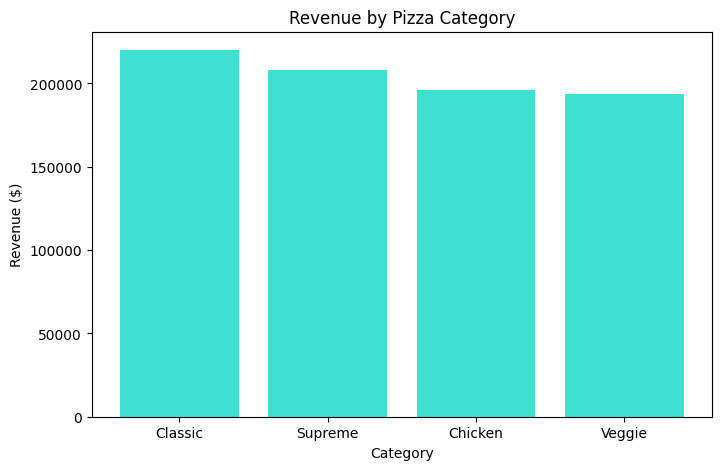

In [564]:
plt.figure(figsize=(8,5))
plt.bar(category_revenue.index, category_revenue.values, color='turquoise')

plt.title("Revenue by Pizza Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)

plt.show()

##### Insight

This analysis highlights the most profitable pizza category.

The restaurant can focus its marketing efforts on the best-performing category while exploring ways to improve sales in lower-performing categories.

### Revenue by Pizza Size

This analysis identifies which pizza size generates the highest revenue.

In [565]:
size_revenue = (sales.groupby("size")["revenue"].sum().sort_values(ascending=False))

size_revenue

,revenue
size,
L,375318.70
M,249382.25
S,178076.50
XL,14076.00
XXL,1006.60


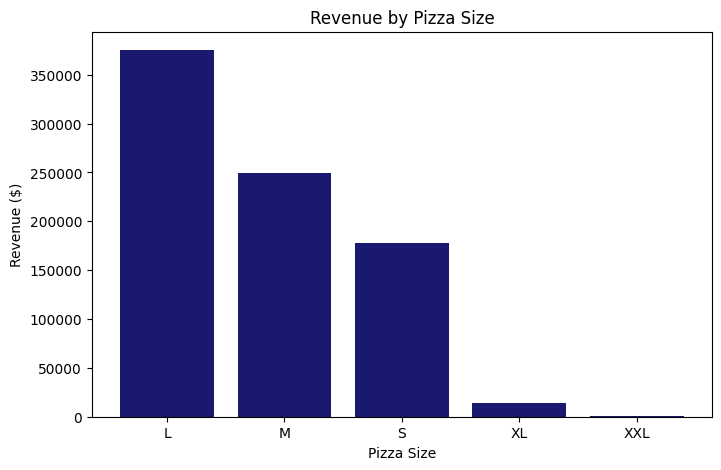

In [566]:
plt.figure(figsize=(8,5))
plt.bar(size_revenue.index, size_revenue.values, color='midnightblue')

plt.title("Revenue by Pizza Size")
plt.xlabel("Pizza Size")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)

plt.show()

##### Insight

The most profitable pizza size contributes the largest share of total revenue.

Understanding customer preferences for pizza sizes can assist in inventory planning and pricing decisions.

### Average Number of Pizzas per Order

This analysis measures the average quantity of pizzas purchased in each customer order.

In [567]:
average_pizzas = sales["quantity"].sum() / sales["order_id"].nunique()

print(f"Average Pizzas per Order: {average_pizzas:.2f}")

Average Pizzas per Order: 2.32


##### Insight

The average number of pizzas purchased per order helps estimate customer buying behavior.

This metric can also be useful when designing meal deals or promotional bundles.

### Highest Revenue-Generating Pizza

Instead of looking only at quantity sold, this analysis identifies the pizza that generated the highest total revenue.

In [568]:
highest_revenue_pizza = (sales.groupby("name")["revenue"].sum().sort_values(ascending=False))

highest_revenue_pizza.head(10)

,revenue
name,
The Thai Chicken Pizza,43434.25
The Barbecue Chicken Pizza,42768.00
The California Chicken Pizza,41409.50
The Classic Deluxe Pizza,38180.50
The Spicy Italian Pizza,34831.25
The Southwest Chicken Pizza,34705.75
The Italian Supreme Pizza,33476.75
The Hawaiian Pizza,32273.25
The Four Cheese Pizza,32265.70


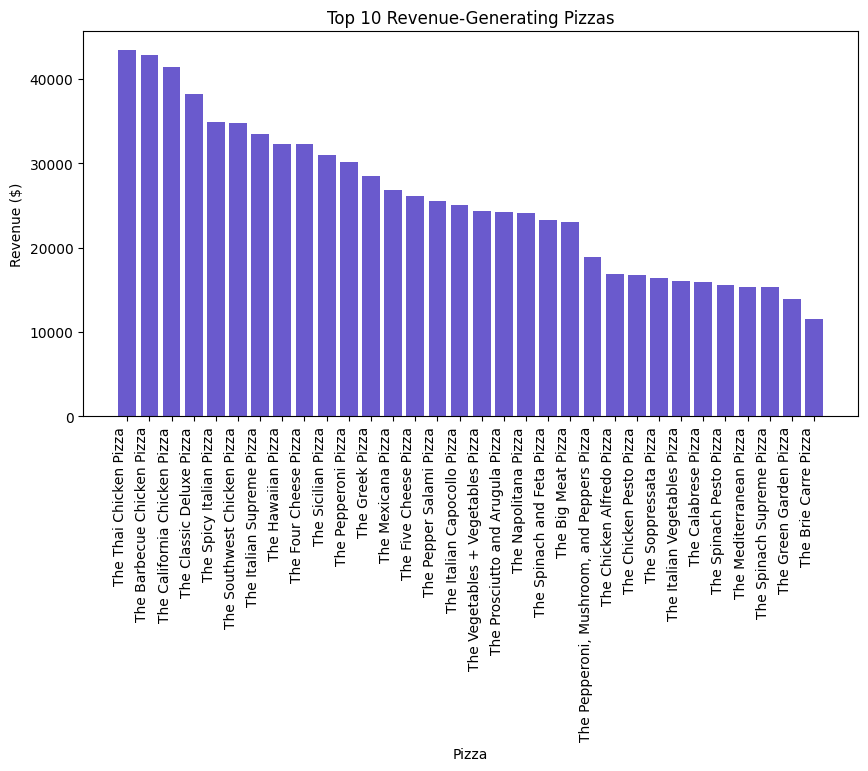

In [569]:
plt.figure(figsize=(10,5))
plt.bar(highest_revenue_pizza.index, highest_revenue_pizza.values, color='slateblue')

plt.title("Top 10 Revenue-Generating Pizzas")
plt.xlabel("Pizza")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=90, ha="right")

plt.show()

##### Insight

The pizza with the highest revenue is not necessarily the one with the highest quantity sold.

Higher-priced pizzas may generate more revenue even if fewer units are sold.

#**Conclusion**

This analysis successfully examined the pizza sales dataset and provided valuable insights into the restaurant's sales performance during the period covered by the data.

The dataset was found to contain sales records from **1st January 2015** to **31st December 2015**, representing one full year of business operations.

The total revenue generated during the observed period was **817,860.05**, with a total of **49,574 pizzas** sold across **21,350 customer orders**. The restaurant offers **32 different pizza types**, and the average price of a pizza was found to be **16.49**.

Further analysis showed that customer demand was highest at **12:00 P.M.**, making it the peak hour of sales, while **Friday** recorded the highest sales among all days of the week. Monthly sales remained relatively stable throughout the year with moderate fluctuations, with **July recording the highest revenue**, while **September and October** recorded comparatively lower revenue.

The sales analysis also revealed differences in the popularity of pizzas on the menu. **The Brie Carre Pizza** was identified as the least-selling pizza, recording only **490 sales** during the observed period, while several other pizzas also recorded fewer than **1,000 sales**, suggesting lower customer demand for those menu items.

Finally, the average number of pizzas ordered per customer order was **2.32**, indicating that customers typically purchased about two pizzas per transaction.

Overall, the analysis provides a clear understanding of the restaurant's sales performance, customer purchasing behaviour, and product popularity. These findings can support informed business decisions regarding inventory management, menu optimization, pricing strategies, and promotional activities aimed at improving overall sales performance.